**Imports**

In [50]:
import os
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)
from tensorflow.keras.utils import to_categorical

print("Libraries imported")

Libraries imported


**Dataset Path**

In [59]:
for root, dirs, files in os.walk("/kaggle/input"):
    if "NORMAL" in dirs and "PNEUMONIA" in dirs:
        print(root)

/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/__MACOSX/chest_xray/train
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/val
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/test
/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train


In [72]:
DATASET_PATH = "/kaggle/input/datasets/paultimothymooney/chest-xray-pneumonia/chest_xray/train"

In [73]:
print(os.path.exists(DATASET_PATH))
print(os.listdir(DATASET_PATH))

True
['PNEUMONIA', 'NORMAL']


**Dataset Loader**

In [74]:
def load_dataset(sample_size):

    normal_path = os.path.join(DATASET_PATH, "NORMAL")
    pneumonia_path = os.path.join(DATASET_PATH, "PNEUMONIA")

    per_class = sample_size // 2

    normal_files = random.sample(
        os.listdir(normal_path),
        per_class
    )

    pneumonia_files = random.sample(
        os.listdir(pneumonia_path),
        per_class
    )

    images = []
    labels = []

    for file in normal_files:

        img = Image.open(
            os.path.join(normal_path, file)
        )

        img = img.convert("RGB")
        img = img.resize((224, 224))

        images.append(np.array(img))
        labels.append(0)

    for file in pneumonia_files:

        img = Image.open(
            os.path.join(pneumonia_path, file)
        )

        img = img.convert("RGB")
        img = img.resize((224, 224))

        images.append(np.array(img))
        labels.append(1)

    X = np.array(images) / 255.0
    y = np.array(labels)

    return X, y

**CNN Model**

In [75]:
def create_cnn():

    model = Sequential([

        Conv2D(
            32,
            (3,3),
            activation='relu',
            input_shape=(224,224,3)
        ),

        MaxPooling2D(),

        Conv2D(
            64,
            (3,3),
            activation='relu'
        ),

        MaxPooling2D(),

        Conv2D(
            128,
            (3,3),
            activation='relu'
        ),

        MaxPooling2D(),

        Flatten(),

        Dense(
            128,
            activation='relu'
        ),

        Dropout(0.5),

        Dense(
            1,
            activation='sigmoid'
        )
    ])

    model.compile(
        optimizer='adam',
        loss='binary_crossentropy',
        metrics=['accuracy']
    )

    return model

**Experiment Loop**

In [76]:
dataset_sizes = [200, 500, 1000]

results = []

**Training**

In [77]:
for size in dataset_sizes:

    print(f"\nTraining CNN with {size} images")

    X, y = load_dataset(size)

    X_train, X_val, y_train, y_val = train_test_split(
        X,
        y,
        test_size=0.20,
        random_state=42,
        stratify=y
    )

    model = create_cnn()

    start_time = time.time()

    history = model.fit(
        X_train,
        y_train,
        validation_data=(X_val, y_val),
        epochs=10,
        batch_size=16,
        verbose=1
    )

    end_time = time.time()

    training_time = end_time - start_time

    val_loss, val_acc = model.evaluate(
        X_val,
        y_val,
        verbose=0
    )

    results.append({
        "Dataset Size": size,
        "Accuracy": round(val_acc * 100, 2),
        "Loss": round(val_loss, 4),
        "Training Time": round(training_time, 2)
    })

    print(
        f"Accuracy: {val_acc:.4f} | "
        f"Loss: {val_loss:.4f} | "
        f"Time: {training_time:.2f} sec"
    )


Training CNN with 200 images


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
2026-06-20 06:10:34.516080: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Epoch 1/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 12s 1s/step - accuracy: 0.4500 - loss: 1.2290 - val_accuracy: 0.5000 - val_loss: 0.6908
Epoch 2/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5562 - loss: 0.6680 - val_accuracy: 0.7750 - val_loss: 0.6543
Epoch 3/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 976ms/step - accuracy: 0.7625 - loss: 0.5634 - val_accuracy: 0.5750 - val_loss: 0.6346
Epoch 4/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 977ms/step - accuracy: 0.8687 - loss: 0.4057 - val_accuracy: 0.7250 - val_loss: 0.5314
Epoch 5/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 978ms/step - accuracy: 0.9375 - loss: 0.3006 - val_accuracy: 0.8000 - val_loss: 0.5657
Epoch 6/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 978ms/step - accuracy: 0.9312 - loss: 0.2047 - val_accuracy: 0.7250 - val_loss: 1.0783
Epoch 7/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 971ms/step - accuracy: 0.9250 - loss: 0.1985 - val_accuracy: 0.7750 - val_loss: 0.6487
Epoch 8/10
10/10 ━━━━━━━━━━━━━━━━━━━━ 10s 966ms/step - accuracy: 0.9688 - loss: 0.1049 - val_accuracy: 

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 27s 1s/step - accuracy: 0.6050 - loss: 0.7831 - val_accuracy: 0.8900 - val_loss: 0.4503
Epoch 2/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.8125 - loss: 0.4522 - val_accuracy: 0.9000 - val_loss: 0.2788
Epoch 3/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9000 - loss: 0.2872 - val_accuracy: 0.9200 - val_loss: 0.2470
Epoch 4/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 1s/step - accuracy: 0.9075 - loss: 0.2432 - val_accuracy: 0.9000 - val_loss: 0.2815
Epoch 5/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 959ms/step - accuracy: 0.9325 - loss: 0.2168 - val_accuracy: 0.9200 - val_loss: 0.1770
Epoch 6/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 999ms/step - accuracy: 0.9325 - loss: 0.1809 - val_accuracy: 0.9200 - val_loss: 0.1770
Epoch 7/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 25s 993ms/step - accuracy: 0.9500 - loss: 0.1506 - val_accuracy: 0.9300 - val_loss: 0.1781
Epoch 8/10
25/25 ━━━━━━━━━━━━━━━━━━━━ 24s 955ms/step - accuracy: 0.9625 - loss: 0.1017 - val_accuracy: 0.9500

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 52s 1s/step - accuracy: 0.6913 - loss: 0.6170 - val_accuracy: 0.8100 - val_loss: 0.5409
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 996ms/step - accuracy: 0.8763 - loss: 0.3209 - val_accuracy: 0.9300 - val_loss: 0.1788
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 961ms/step - accuracy: 0.9175 - loss: 0.2130 - val_accuracy: 0.9550 - val_loss: 0.1610
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 959ms/step - accuracy: 0.9350 - loss: 0.1581 - val_accuracy: 0.9650 - val_loss: 0.1358
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 84s 998ms/step - accuracy: 0.9538 - loss: 0.1400 - val_accuracy: 0.9250 - val_loss: 0.1824
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 50s 997ms/step - accuracy: 0.9025 - loss: 0.2326 - val_accuracy: 0.9650 - val_loss: 0.1260
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 959ms/step - accuracy: 0.9638 - loss: 0.1223 - val_accuracy: 0.9350 - val_loss: 0.1660
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 48s 954ms/step - accuracy: 0.9775 - loss: 0.0785 - val_accurac

**Results Table**

In [78]:
results_df = pd.DataFrame(results)

results_df

,Dataset Size,Accuracy,Loss,Training Time
0,200,75.0,0.6379,100.99
1,500,95.0,0.1287,248.41
2,1000,97.5,0.1119,523.79


**Save CSV**

In [82]:
results_df.to_csv(
    "cnn_results.csv",
    index=False
)

**Accuracy Graph**

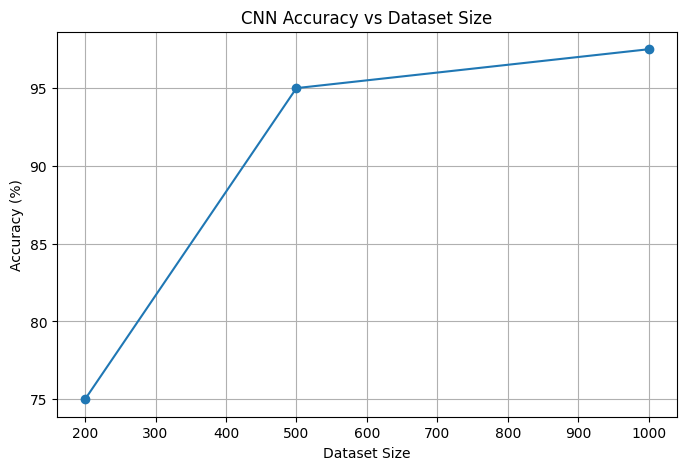

In [83]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Dataset Size"],
    results_df["Accuracy"],
    marker="o"
)

plt.title("CNN Accuracy vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Accuracy (%)")

plt.grid(True)

plt.show()

**Loss Graph**

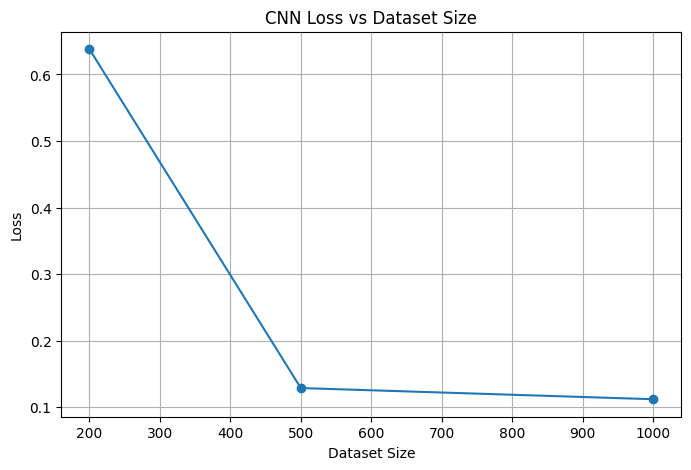

In [84]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Dataset Size"],
    results_df["Loss"],
    marker="o"
)

plt.title("CNN Loss vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Loss")

plt.grid(True)

plt.show()

**Training Time Graph**

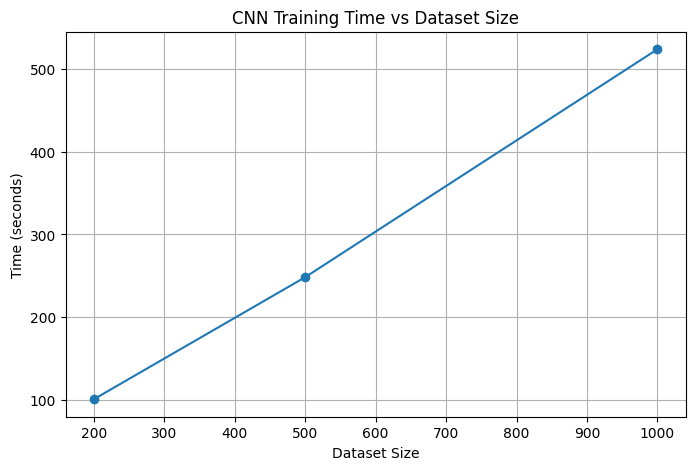

In [85]:
plt.figure(figsize=(8,5))

plt.plot(
    results_df["Dataset Size"],
    results_df["Training Time"],
    marker="o"
)

plt.title("CNN Training Time vs Dataset Size")
plt.xlabel("Dataset Size")
plt.ylabel("Time (seconds)")

plt.grid(True)

plt.show()